# 2.3 ガウス分布 (The Gaussian Distribution)

本ノートブックでは、連続確率分布の中で最も中心的な役割を果たす**多変量ガウス分布（正規分布）**について、その幾何学的性質、条件付き分布と周辺分布、線形ガウスモデル、最尤推定と逐次推定、ベイズ推論、頑健なスチューデントのt分布、周期変数のためのフォン・ミーゼス分布、そして混合ガウス分布までを体系的に学びます。

## 2.3.0 ガウス分布の幾何学的性質と二次形式

$D$ 次元実ベクトル $\mathbf{x}$ に対するガウス分布は以下のように定義されます。

$$ \mathcal{N}(\mathbf{x} | \boldsymbol{\mu}, \boldsymbol{\Sigma}) = \frac{1}{(2\pi)^{D/2} |\boldsymbol{\Sigma}|^{1/2}} \exp\left( -\frac{1}{2} (\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu}) \right) $$

ここで、$\boldsymbol{\mu}$ は $D$ 次元の平均ベクトル、$\boldsymbol{\Sigma}$ は $D \times D$ の対称な共分散行列です。

### マハラノビス距離 (Mahalanobis Distance)
指数部の二次形式
$$ \Delta^2 = (\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu}) $$
は、$\mathbf{x}$ と $\boldsymbol{\mu}$ の間の**マハラノビス距離の二乗**と呼ばれます。
共分散行列 $\boldsymbol{\Sigma}$ の正規直交固有ベクトル $\mathbf{u}_i$ と固有値 $\lambda_i$ を用いて固有値分解を行うと、
$$ \boldsymbol{\Sigma} = \sum_{i=1}^D \lambda_i \mathbf{u}_i \mathbf{u}_i^T, \quad \boldsymbol{\Sigma}^{-1} = \sum_{i=1}^D \frac{1}{\lambda_i} \mathbf{u}_i \mathbf{u}_i^T $$
となり、固有ベクトル基底への座標変換 $y_i = \mathbf{u}_i^T (\mathbf{x} - \boldsymbol{\mu})$ を行うと、
$$ \Delta^2 = \sum_{i=1}^D \frac{y_i^2}{\lambda_i} $$
と楕円体の方程式になります。等確率面は、主軸が固有ベクトル $\mathbf{u}_i$ 方向を向き、軸の長さが $\sqrt{\lambda_i}$ に比例する楕円面を成します。

## 2.3.1 & 2.3.2 条件付きガウス分布と周辺ガウス分布

ガウス分布の極めて強力な性質として、**条件付き分布も周辺分布もすべてガウス分布になる**という点が挙げられます。

ベクトル $\mathbf{x}$ を2つの部分ベクトル $\mathbf{x}_a$ ($M$ 次元) と $\mathbf{x}_b$ ($D-M$ 次元) に分割します。
$$ \mathbf{x} = \begin{pmatrix} \mathbf{x}_a \\ \mathbf{x}_b \end{pmatrix}, \quad \boldsymbol{\mu} = \begin{pmatrix} \boldsymbol{\mu}_a \\ \boldsymbol{\mu}_b \end{pmatrix}, \quad \boldsymbol{\Sigma} = \begin{pmatrix} \boldsymbol{\Sigma}_{aa} & \boldsymbol{\Sigma}_{ab} \\ \boldsymbol{\Sigma}_{ba} & \boldsymbol{\Sigma}_{bb} \end{pmatrix} $$
共分散行列の逆行列である**精度行列 (Precision Matrix)** $\boldsymbol{\Lambda} = \boldsymbol{\Sigma}^{-1}$ も同様に分割します。
$$ \boldsymbol{\Lambda} = \begin{pmatrix} \boldsymbol{\Lambda}_{aa} & \boldsymbol{\Lambda}_{ab} \\ \boldsymbol{\Lambda}_{ba} & \boldsymbol{\Lambda}_{bb} \end{pmatrix} $$

### 条件付きガウス分布 (PRML 式 (2.81), (2.82))
一方の変数 $\mathbf{x}_b$ を観測して固定したときの $\mathbf{x}_a$ の条件付き分布 $p(\mathbf{x}_a | \mathbf{x}_b)$ は、精度行列を用いると極めて簡潔に表現できます。
$$ p(\mathbf{x}_a | \mathbf{x}_b) = \mathcal{N}(\mathbf{x}_a | \boldsymbol{\mu}_{a|b}, \boldsymbol{\Sigma}_{a|b}) $$
$$ \boldsymbol{\mu}_{a|b} = \boldsymbol{\mu}_a - \boldsymbol{\Lambda}_{aa}^{-1} \boldsymbol{\Lambda}_{ab} (\mathbf{x}_b - \boldsymbol{\mu}_b) = \boldsymbol{\mu}_a + \boldsymbol{\Sigma}_{ab} \boldsymbol{\Sigma}_{bb}^{-1} (\mathbf{x}_b - \boldsymbol{\mu}_b) $$
$$ \boldsymbol{\Sigma}_{a|b} = \boldsymbol{\Lambda}_{aa}^{-1} = \boldsymbol{\Sigma}_{aa} - \boldsymbol{\Sigma}_{ab} \boldsymbol{\Sigma}_{bb}^{-1} \boldsymbol{\Sigma}_{ba} $$
特筆すべき点として、**条件付き共分散 $\boldsymbol{\Sigma}_{a|b}$ は観測値 $\mathbf{x}_b$ の値そのものには依存しない**（一定）という性質があります。

### 周辺ガウス分布 (PRML 式 (2.98), (2.99))
もう一方の変数を積分消去した周辺分布 $p(\mathbf{x}_a) = \int p(\mathbf{x}_a, \mathbf{x}_b) d\mathbf{x}_b$ は、共分散行列の対応するブロックから直接得られます。
$$ p(\mathbf{x}_a) = \mathcal{N}(\mathbf{x}_a | \boldsymbol{\mu}_a, \boldsymbol{\Sigma}_{aa}) $$

Plot saved to: result/fig2_gaussian_condition_marginal.png


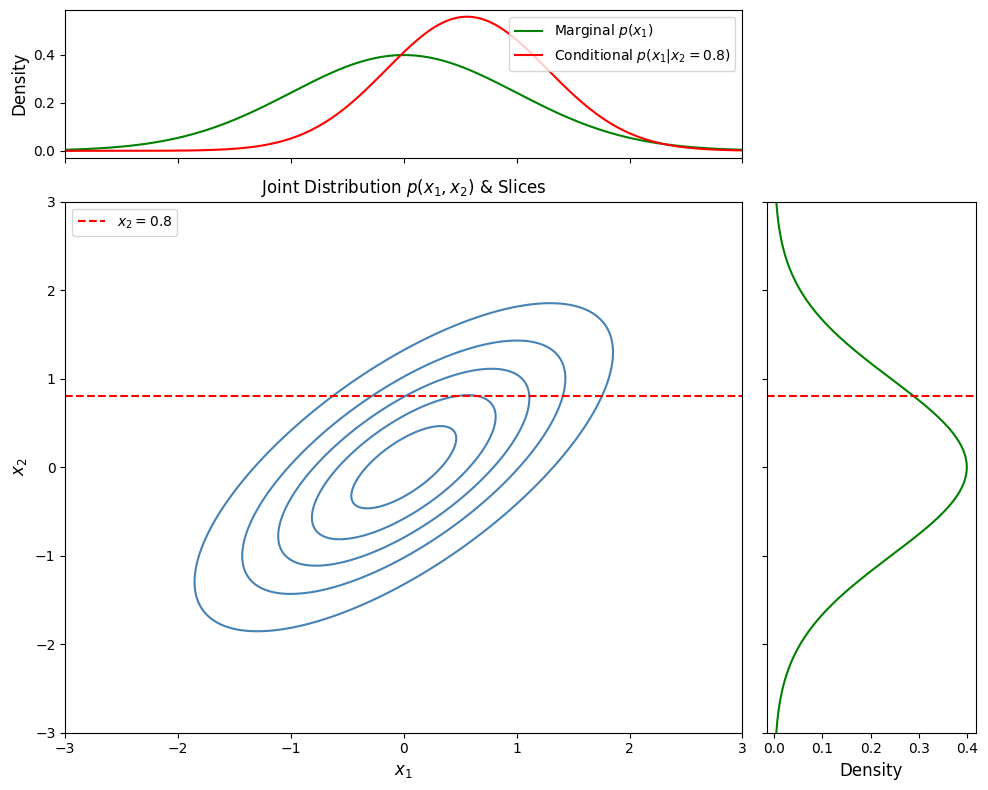

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
setup_style()

# 2次元ガウス分布のパラメータ
mu = np.array([0.0, 0.0])
Sigma = np.array([[1.0, 0.7],
                  [0.7, 1.0]])

# x2 = 0.8 を観測したときの条件付き分布 p(x1 | x2 = 0.8)
x2_val = 0.8
# 条件付き平均と分散の計算
mu_cond = mu[0] + Sigma[0, 1] * (1.0 / Sigma[1, 1]) * (x2_val - mu[1])
var_cond = Sigma[0, 0] - Sigma[0, 1] * (1.0 / Sigma[1, 1]) * Sigma[1, 0]

x1_grid = np.linspace(-3, 3, 200)
x2_grid = np.linspace(-3, 3, 200)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
pos = np.dstack((X1, X2))
rv = stats.multivariate_normal(mu, Sigma)
Z = rv.pdf(pos)

fig = plt.figure(figsize=(10, 8))
# 2次元等高線
ax_joint = plt.subplot2grid((4, 4), (1, 0), colspan=3, rowspan=3)
ax_joint.contour(X1, X2, Z, levels=6, colors='steelblue')
ax_joint.axhline(x2_val, color='red', linestyle='--', label=f'$x_2 = {x2_val}$')
ax_joint.set_xlabel('$x_1$')
ax_joint.set_ylabel('$x_2$')
ax_joint.legend(loc='upper left')
ax_joint.set_title('Joint Distribution $p(x_1, x_2)$ & Slices', fontsize=12)

# 上部: 周辺分布 p(x1) と 条件付き分布 p(x1 | x2 = 0.8)
ax_top = plt.subplot2grid((4, 4), (0, 0), colspan=3, sharex=ax_joint)
p_x1_marg = stats.norm.pdf(x1_grid, mu[0], np.sqrt(Sigma[0, 0]))
p_x1_cond = stats.norm.pdf(x1_grid, mu_cond, np.sqrt(var_cond))
ax_top.plot(x1_grid, p_x1_marg, 'g-', label='Marginal $p(x_1)$')
ax_top.plot(x1_grid, p_x1_cond, 'r-', label=r'Conditional $p(x_1 | x_2=0.8)$')
ax_top.legend(loc='upper right')
ax_top.set_ylabel('Density')
ax_top.tick_params(labelbottom=False)

# 右部: 周辺分布 p(x2)
ax_right = plt.subplot2grid((4, 4), (1, 3), rowspan=3, sharey=ax_joint)
p_x2_marg = stats.norm.pdf(x2_grid, mu[1], np.sqrt(Sigma[1, 1]))
ax_right.plot(p_x2_marg, x2_grid, 'g-', label='Marginal $p(x_2)$')
ax_right.axhline(x2_val, color='red', linestyle='--')
ax_right.set_xlabel('Density')
ax_right.tick_params(labelleft=False)

plt.tight_layout()
save_plot(fig, 'result', 'fig2_gaussian_condition_marginal.png')
plt.show()

## 2.3.3 ガウス変数に対するベイズの定理 (線形ガウスモデル)

事前分布がガウス分布であり、観測変数の条件付き分布が平均パラメータに関して線形であるモデル（**線形ガウスモデル**）を考えます。
$$ p(\mathbf{x}) = \mathcal{N}(\mathbf{x} | \boldsymbol{\mu}, \boldsymbol{\Lambda}^{-1}) $$
$$ p(\mathbf{y} | \mathbf{x}) = \mathcal{N}(\mathbf{y} | \mathbf{A}\mathbf{x} + \mathbf{b}, \mathbf{L}^{-1}) $$

このとき、$\mathbf{y}$ の周辺分布および観測値 $\mathbf{y}$ を得た後の $\mathbf{x}$ の事後分布は閉じた形で解析的に求まります（PRML 式 (2.115)）。

### 周辺分布 $p(\mathbf{y})$
$$ p(\mathbf{y}) = \mathcal{N}(\mathbf{y} | \mathbf{A}\boldsymbol{\mu} + \mathbf{b}, \mathbf{L}^{-1} + \mathbf{A}\boldsymbol{\Lambda}^{-1}\mathbf{A}^T) $$

### 事後分布 $p(\mathbf{x} | \mathbf{y})$
$$ p(\mathbf{x} | \mathbf{y}) = \mathcal{N}(\mathbf{x} | \boldsymbol{\Sigma}(\mathbf{A}^T \mathbf{L}(\mathbf{y} - \mathbf{b}) + \boldsymbol{\Lambda}\boldsymbol{\mu}), \boldsymbol{\Sigma}) $$
ただし、事後精度行列（共分散行列の逆行列）は
$$ \boldsymbol{\Sigma}^{-1} = \boldsymbol{\Lambda} + \mathbf{A}^T \mathbf{L} \mathbf{A} $$
です。この線形ガウスモデルは、カルマンフィルタや第3章の線形回帰、ガウス過程の数学的基盤となっています。

## 2.3.4 & 2.3.5 ガウス分布の最尤推定と Robbins-Monro アルゴリズム

### 最尤推定量とバイアス
i.i.d. な観測データ $\mathbf{x}_1, \dots, \mathbf{x}_N$ に対する対数尤度を最大化すると、最尤解が得られます。
$$ \boldsymbol{\mu}_{\mathrm{ML}} = \frac{1}{N} \sum_{n=1}^N \mathbf{x}_n, \quad \boldsymbol{\Sigma}_{\mathrm{ML}} = \frac{1}{N} \sum_{n=1}^N (\mathbf{x}_n - \boldsymbol{\mu}_{\mathrm{ML}})(\mathbf{x}_n - \boldsymbol{\mu}_{\mathrm{ML}})^T $$
平均の最尤推定量は不偏ですが（$\mathbb{E}[\boldsymbol{\mu}_{\mathrm{ML}}] = \boldsymbol{\mu}$）、共分散の最尤推定量は真の共分散よりも過小評価するバイアスを持ちます。
$$ \mathbb{E}[\boldsymbol{\Sigma}_{\mathrm{ML}}] = \frac{N - 1}{N} \boldsymbol{\Sigma} $$
不偏分散とするには係数を $\frac{1}{N-1}$ に補正します。

### Robbins-Monro による逐次推定 (Sequential Estimation)
全データを一度に保持せず、データが1点ずつ到着するたびに逐次的にパラメータを更新するアルゴリズムを導出します。
平均の更新式は以下のように表現できます。
$$ \boldsymbol{\mu}^{(N)} = \boldsymbol{\mu}^{(N-1)} + \frac{1}{N} (\mathbf{x}_N - \boldsymbol{\mu}^{(N-1)}) $$
これは、確率的求根アルゴリズムである**Robbins-Monro アルゴリズム**（ステップサイズ $a_N = 1/N$）の直接の適用例となっています。

Plot saved to: result/fig2_robbins_monro.png


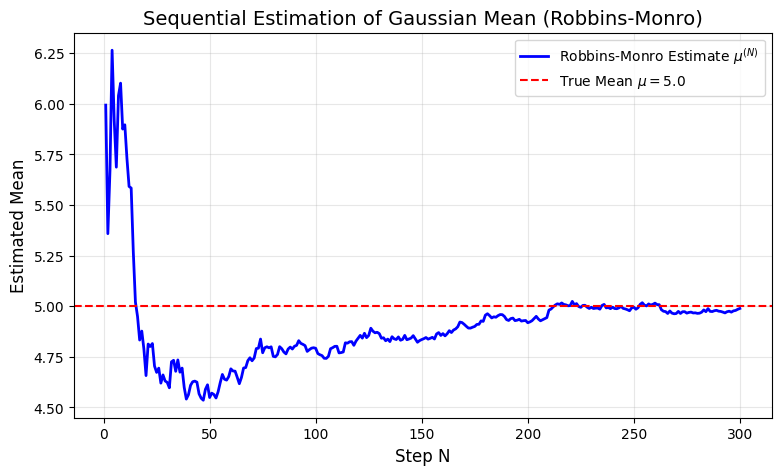

In [2]:
# Robbins-Monro による平均の逐次推定のシミュレーション
np.random.seed(42)
true_mean = 5.0
true_std = 2.0
N_samples = 300
data_stream = np.random.normal(true_mean, true_std, N_samples)

estimated_means = []
current_mean = 0.0  # 初期値

for n, x in enumerate(data_stream, start=1):
    # Robbins-Monro 更新: mu^(n) = mu^(n-1) + (1/n) * (x - mu^(n-1))
    current_mean = current_mean + (1.0 / n) * (x - current_mean)
    estimated_means.append(current_mean)

fig = plt.figure(figsize=(9, 5))
plt.plot(range(1, N_samples + 1), estimated_means, 'b-', label='Robbins-Monro Estimate $\mu^{(N)}$', lw=2)
plt.axhline(true_mean, color='red', linestyle='--', label=f'True Mean $\mu = {true_mean}$')
plt.title('Sequential Estimation of Gaussian Mean (Robbins-Monro)')
plt.xlabel('Step N')
plt.ylabel('Estimated Mean')
plt.grid(True, alpha=0.3)
plt.legend()
save_plot(fig, 'result', 'fig2_robbins_monro.png')
plt.show()

## 2.3.6 ガウス分布に対するベイズ推論

パラメータに対する共役事前分布の選択：

1. **平均 $\mu$ が未知、分散 $\sigma^2$ が既知**:
   - 尤度関数は $\mu$ の二次形式の指数なので、共役事前分布は**ガウス分布** $p(\mu) = \mathcal{N}(\mu | \mu_0, \sigma_0^2)$ です。
   - 事後分布もガウス分布となり、精度（分散の逆数）は観測ごとに単純加算されます。
2. **分散 $\sigma^2$ (精度 $\tau = 1/\sigma^2$) が未知、平均 $\mu$ が既知**:
   - 共役事前分布は**ガンマ分布** $p(\tau) = \mathrm{Gam}(\tau | a_0, b_0) = \frac{1}{\Gamma(a_0)} b_0^{a_0} \tau^{a_0 - 1} e^{-b_0 \tau}$ です。
   - 多変量の場合は**ウィシャート分布 (Wishart distribution)** となります。
3. **平均 $\mu$ と精度 $\tau$ の双方が未知**:
   - 共役事前分布は**ガウス-ガンマ分布 (Gaussian-Gamma distribution)**:
     $$ p(\mu, \tau) = \mathcal{N}(\mu | \mu_0, (\beta \tau)^{-1}) \mathrm{Gam}(\tau | a, b) $$
   - 多変量の場合は**ガウス-ウィシャート分布**となります。

## 2.3.7 スチューデントのt分布と外れ値に対する頑健性 (Robustness)

ガウス分布の精度パラメータ $\tau$ にガンマ分布 $p(\tau|a, b)$ を事前分布として与え、$\tau$ について周辺化（積分消去）を行うと、**スチューデントのt分布 (Student's t-distribution)** が得られます。

$$ p(x|\mu, a, b) = \int_0^\infty \mathcal{N}(x | \mu, \tau^{-1}) \mathrm{Gam}(\tau | a, b) d\tau = \frac{\Gamma(a + 1/2)}{\Gamma(a)} \left(\frac{b}{\pi}\right)^{1/2} \left[ 1 + \frac{(x-\mu)^2}{2b} \right]^{-a - 1/2} $$

自由度 $\nu = 2a$、精度 $\lambda = a/b$ と置くと標準的な形式になります。
$$ \mathrm{St}(x | \mu, \lambda, \nu) = \frac{\Gamma(\frac{\nu + 1}{2})}{\Gamma(\frac{\nu}{2})} \left( \frac{\lambda}{\pi \nu} \right)^{1/2} \left[ 1 + \frac{\lambda(x - \mu)^2}{\nu} \right]^{-\frac{\nu + 1}{2}} $$

### 外れ値に対するロバスト性 (Robustness to Outliers)
- $\nu \to \infty$ のとき、t分布はガウス分布 $\mathcal{N}(x|\mu, \lambda^{-1})$ に収束します。
- 有限の $\nu$ では、裾野がべき乗（多項式）で減衰するため、ガウス分布（指数関数的減衰）よりもはるかに厚い裾野（ヘビーテール）を持ちます。
- **外れ値が存在するデータに対する最尤推定において、ガウス分布は外れ値に強く引っ張られて平均が歪んでしまいますが、t分布は外れ値の影響を自動的に抑制（重みを下げる）します。**

Plot saved to: result/fig2_robust_student_t.png


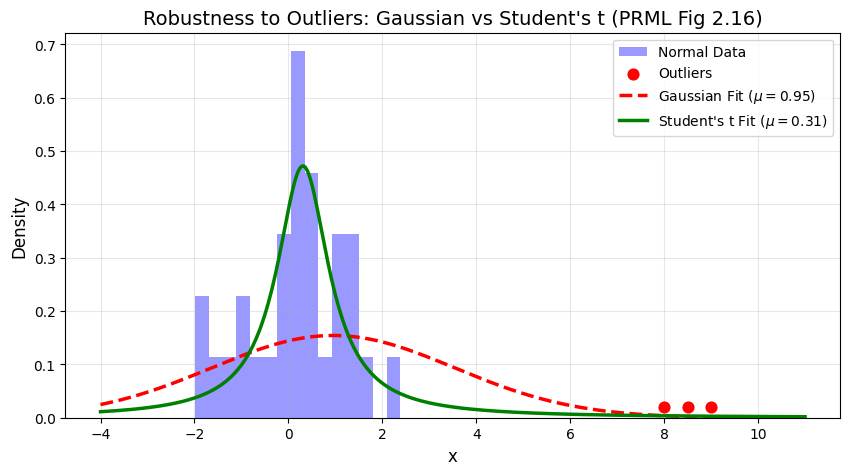

In [3]:
from scipy.optimize import minimize
from common.distribution_utils import student_t_pdf

# PRML Figure 2.16 の再現実験: 外れ値に対するガウス分布 vs t分布の最尤推定
np.random.seed(10)
clean_data = np.random.normal(0.0, 1.0, 30)
outliers = np.array([8.0, 8.5, 9.0]) # 強い外れ値を混入
all_data = np.concatenate([clean_data, outliers])

# ガウス分布の最尤推定: 標本平均
mu_gauss = np.mean(all_data)
var_gauss = np.var(all_data)

# t分布の最尤推定 (nu = 1.0 を固定)
def neg_log_lik_t(params):
    mu_t, lam_t = params
    if lam_t <= 0: return 1e10
    pdf = student_t_pdf(all_data, mu_t, lam_t, nu=1.0)
    return -np.sum(np.log(np.maximum(pdf, 1e-15)))

res = minimize(neg_log_lik_t, x0=[0.0, 1.0])
mu_t, lam_t = res.x

# プロット
x_axis = np.linspace(-4, 11, 400)
p_gauss = stats.norm.pdf(x_axis, mu_gauss, np.sqrt(var_gauss))
p_t = student_t_pdf(x_axis, mu_t, lam_t, nu=1.0)

fig = plt.figure(figsize=(10, 5))
plt.hist(clean_data, bins=15, density=True, alpha=0.4, color='blue', label='Normal Data')
plt.scatter(outliers, [0.02]*len(outliers), color='red', s=60, zorder=5, label='Outliers')

plt.plot(x_axis, p_gauss, 'r--', lw=2.5, label=f'Gaussian Fit ($\mu={mu_gauss:.2f}$)')
plt.plot(x_axis, p_t, 'g-', lw=2.5, label=f"Student's t Fit ($\mu={mu_t:.2f}$)")

plt.title("Robustness to Outliers: Gaussian vs Student's t (PRML Fig 2.16)")
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
save_plot(fig, 'result', 'fig2_robust_student_t.png')
plt.show()

## 2.3.8 周期変数とフォン・ミーゼス分布 (von Mises Distribution)

風向や時刻、周期的な角度 $\theta \in [0, 2\pi)$ を扱う場合、通常のユークリッド幾何での平均値計算は破綻します。
例えば $\theta_1 = 0.1$ ラジアンと $\theta_2 = 2\pi - 0.1$ ラジアンの算術平均は $\pi$（真逆の方向）になってしまいます。

角度変数は単位円周上の点 $\mathbf{x} = (\cos \theta, \sin \theta)^T$ として扱い、2次元ガウス分布を単位円上に制限することで**フォン・ミーゼス分布**が導かれます。

$$ p(\theta | \theta_0, m) = \frac{1}{2\pi I_0(m)} \exp\{ m \cos(\theta - \theta_0) \} $$

- $\theta_0$: 平均方向
- $m$: 集中度パラメータ (ガウス分布の精度 $\sigma^{-2}$ に相当)
- $I_0(m)$: 第1種 0次の変形ベッセル関数 (規格化定数)

Plot saved to: result/fig2_von_mises.png


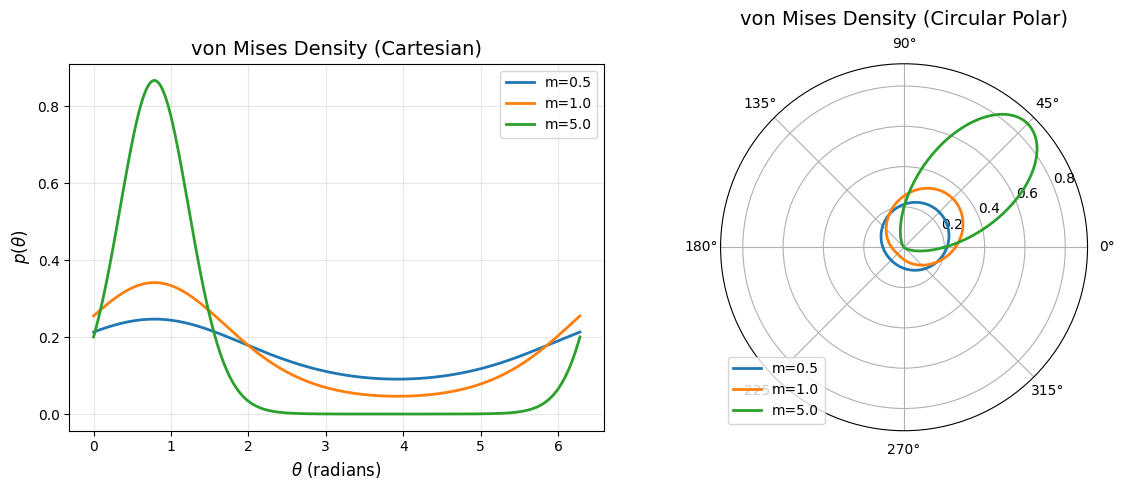

In [4]:
from common.distribution_utils import von_mises_pdf

theta = np.linspace(0, 2 * np.pi, 300)
mu_angle = np.pi / 4.0 # 45度
kappas = [0.5, 1.0, 5.0]

fig = plt.figure(figsize=(12, 5))

# 直交座標でのプロット
ax1 = plt.subplot(1, 2, 1)
for k in kappas:
    pdf = von_mises_pdf(theta, mu_angle, k)
    ax1.plot(theta, pdf, label=f'm={k}', lw=2)
ax1.set_title('von Mises Density (Cartesian)')
ax1.set_xlabel(r'$\theta$ (radians)')
ax1.set_ylabel(r'$p(\theta)$')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 極座標でのプロット (Figure 2.18)
ax2 = plt.subplot(1, 2, 2, projection='polar')
for k in kappas:
    pdf = von_mises_pdf(theta, mu_angle, k)
    ax2.plot(theta, pdf, label=f'm={k}', lw=2)
ax2.set_title('von Mises Density (Circular Polar)', va='bottom')
ax2.legend(loc='lower left')

plt.tight_layout()
save_plot(fig, 'result', 'fig2_von_mises.png')
plt.show()

## 2.3.9 混合ガウス分布 (Mixtures of Gaussians)

単一のガウス分布は単峰性（1つの山）しか表現できず、複雑なデータ分布を表現するには不十分です。
複数のガウス成分を線形結合した**混合ガウス分布 (Gaussian Mixture Model, GMM)** を用いることで、任意の確率密度を近似できる柔軟な表現力を得られます。

$$ p(\mathbf{x}) = \sum_{k=1}^K \pi_k \mathcal{N}(\mathbf{x} | \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k) $$

- $\pi_k$: 混合係数 (Mixing coefficient), $0 \le \pi_k \le 1, \sum_{k=1}^K \pi_k = 1$
- 潜在変数 $\mathbf{z} \in \{0, 1\}^K$ (1-of-$K$ 表現) を導入すると、
  $$ p(z_k = 1) = \pi_k, \quad p(\mathbf{x} | z_k = 1) = \mathcal{N}(\mathbf{x} | \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k) $$
- **負担率 (Responsibility)**: データ点 $\mathbf{x}$ が成分 $k$ から生成された事後確率
  $$ \gamma(z_k) = p(z_k = 1 | \mathbf{x}) = \frac{\pi_k \mathcal{N}(\mathbf{x} | \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)}{\sum_{j=1}^K \pi_j \mathcal{N}(\mathbf{x} | \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)} $$

Plot saved to: result/fig2_gmm_mixture.png


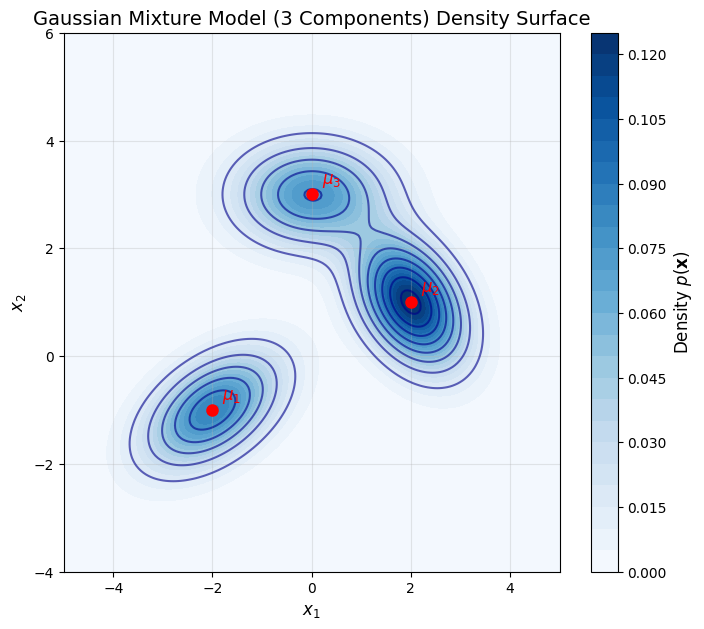

In [5]:
# 3成分混合ガウス分布の可視化
pi = [0.3, 0.4, 0.3]
mus = [np.array([-2.0, -1.0]), np.array([2.0, 1.0]), np.array([0.0, 3.0])]
Sigmas = [
    np.array([[0.8, 0.3], [0.3, 0.5]]),
    np.array([[0.5, -0.2], [-0.2, 0.6]]),
    np.array([[1.0, 0.0], [0.0, 0.4]])
]

x_grid = np.linspace(-5, 5, 200)
y_grid = np.linspace(-4, 6, 200)
X, Y = np.meshgrid(x_grid, y_grid)
pos = np.dstack((X, Y))

Z_gmm = np.zeros_like(X)
for k in range(3):
    rv_k = stats.multivariate_normal(mus[k], Sigmas[k])
    Z_gmm += pi[k] * rv_k.pdf(pos)

fig = plt.figure(figsize=(8, 7))
plt.contourf(X, Y, Z_gmm, levels=25, cmap='Blues')
plt.colorbar(label='Density $p(\mathbf{x})$')
plt.contour(X, Y, Z_gmm, levels=10, colors='darkblue', alpha=0.6)

for k in range(3):
    plt.plot(mus[k][0], mus[k][1], 'ro', markersize=8)
    plt.text(mus[k][0]+0.2, mus[k][1]+0.2, f'$\mu_{k+1}$', color='red', fontsize=12, fontweight='bold')

plt.title('Gaussian Mixture Model (3 Components) Density Surface')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.grid(True, alpha=0.3)
save_plot(fig, 'result', 'fig2_gmm_mixture.png')
plt.show()